<a href="https://colab.research.google.com/github/satvik-venkatesh/word-eq/blob/main/audio-and-word-embeddings-k-fold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://conceptnet.s3.amazonaws.com/downloads/2019/numberbatch/numberbatch-en-19.08.txt.gz

--2021-11-22 15:36:28--  https://conceptnet.s3.amazonaws.com/downloads/2019/numberbatch/numberbatch-en-19.08.txt.gz
Resolving conceptnet.s3.amazonaws.com (conceptnet.s3.amazonaws.com)... 52.217.39.148
Connecting to conceptnet.s3.amazonaws.com (conceptnet.s3.amazonaws.com)|52.217.39.148|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 325403502 (310M) [application/x-gzip]
Saving to: ‘numberbatch-en-19.08.txt.gz’

numberbatch-en-19.0 100%[===================>] 310.33M  39.9MB/s    in 8.0s    

2021-11-22 15:36:37 (39.0 MB/s) - ‘numberbatch-en-19.08.txt.gz’ saved [325403502/325403502]



In [ ]:
!wget http://conceptnet.s3.amazonaws.com/precomputed-data/2016/numberbatch/19.08/mini.h5

--2021-11-22 16:00:04--  http://conceptnet.s3.amazonaws.com/precomputed-data/2016/numberbatch/19.08/mini.h5
Resolving conceptnet.s3.amazonaws.com (conceptnet.s3.amazonaws.com)... 52.216.144.91
Connecting to conceptnet.s3.amazonaws.com (conceptnet.s3.amazonaws.com)|52.216.144.91|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 632948057 (604M) [binary/octet-stream]
Saving to: ‘mini.h5’

mini.h5             100%[===================>] 603.63M  33.3MB/s    in 18s     

2021-11-22 16:00:23 (33.6 MB/s) - ‘mini.h5’ saved [632948057/632948057]



In [ ]:
import shutil

In [ ]:
import gzip
with gzip.open('/content/numberbatch-en-19.08.txt.gz', 'rb') as f:
    file_content = f.read()

In [ ]:
import gzip
import shutil
with gzip.open('/content/numberbatch-en-19.08.txt.gz', 'rb') as f_in:
    with open('/content/numberbatch-en-19.08.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [ ]:
def read_annotation_3(filename, word="warm"):
    events = []
    with open(filename, 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=' ', quotechar='|')
        for i, row in enumerate(spamreader):
          print(row)
          if i >= 50:
            break

In [ ]:
read_annotation_3("/content/numberbatch-en-19.08.txt")

['516782', '300']
['##', '0.0295', '-0.0405', '-0.0341', '0.0837', '-0.0575', '0.0482', '-0.0145', '0.0019', '0.0347', '0.0825', '-0.0735', '0.0083', '-0.0944', '-0.0717', '0.1994', '-0.0107', '-0.0783', '0.0693', '-0.0161', '0.0460', '0.1713', '0.0727', '-0.0983', '-0.0641', '-0.0124', '0.0140', '-0.0473', '0.1162', '0.1127', '-0.0739', '-0.0666', '-0.0631', '-0.0196', '-0.0709', '-0.0302', '-0.1179', '0.0618', '0.0519', '0.0121', '0.0056', '0.0765', '0.0083', '0.0142', '-0.0883', '0.0255', '-0.0015', '0.0748', '-0.0214', '-0.1229', '-0.0017', '-0.0317', '0.0062', '0.0191', '0.1199', '0.0969', '0.0471', '-0.0436', '0.0068', '-0.0418', '0.0152', '0.0222', '-0.1094', '-0.0128', '-0.0608', '0.0089', '-0.0595', '0.1440', '-0.0798', '0.0247', '-0.0462', '0.1096', '0.0880', '-0.0120', '-0.0788', '-0.0957', '-0.0101', '-0.0441', '0.0881', '-0.0223', '0.1191', '0.0082', '0.0629', '-0.1335', '0.0780', '-0.1300', '0.1064', '0.0998', '0.0302', '0.0443', '0.0002', '-0.0337', '0.0083', '0.0378', '

In [ ]:
# Embedding matrix for dict2vec
#generate the embedding matrix

voc2 = vec2.get_vocabulary()
word_index_2 = dict(zip(voc2, range(len(voc2))))

num_tokens = len(voc2)
embedding_dim = 300
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for i, word in enumerate(word_index_2):
    if word == '' or word == '[UNK]':
      embedding_matrix[i] = np.zeros(embedding_dim,)
      print("Missed: " + word)
      continue
    em,hit = read_annotation_2("/content/numberbatch-en-19.08.txt", word)
    if not hit:
      embedding_matrix[i] = np.zeros(embedding_dim,)
      print("Missed: " + word)

    else:
      em_2 = np.array(em[1:-1]).astype(float)
      embedding_matrix[i] = em_2
      print("Added: " + word)

Missed: 
Missed: [UNK]


ValueError: ignored

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_hdf("/content/mini.h5")

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299
/c/de/####er,-2,1,-1,1,0,-1,1,6,-1,0,-1,-1,-3,-5,0,-3,-8,0,0,0,-3,0,2,0,1,1,0,-6,8,0,-3,0,-2,-4,-2,4,-3,0,-4,0,...,-2,1,5,0,0,0,1,0,5,0,3,-6,2,0,3,-8,-4,0,-1,4,3,-1,-3,-4,-4,0,-1,-2,-1,1,-5,7,0,-3,0,2,4,0,0,1
/c/de/###er,-1,1,-4,0,-1,-5,1,0,0,0,0,1,0,3,0,-2,3,0,9,4,0,0,6,5,-6,5,-1,-2,5,-1,3,-4,-9,-2,0,-3,-3,0,1,0,...,-3,-5,0,-3,2,3,1,7,0,2,1,-2,7,1,0,-2,-4,-2,2,-2,4,-2,2,0,4,0,-2,-2,5,-1,0,6,-8,0,-4,-1,5,-2,1,2
/c/de/##cm,-1,-1,0,2,3,-1,1,0,0,1,0,3,0,0,1,-3,3,0,1,0,4,0,0,4,2,3,-1,-5,-5,0,3,0,-1,1,2,0,1,7,0,0,...,0,2,1,-1,0,6,-1,-4,0,0,-5,-2,5,1,9,-3,-3,4,6,0,2,3,-2,5,-4,2,-3,2,-3,3,-1,9,2,-1,-7,3,-7,0,-1,-2
/c/de/##er,0,2,-3,0,0,-2,1,4,2,0,3,0,-3,-3,-4,-5,-7,-3,10,0,-2,0,1,4,0,2,0,-4,3,-1,-2,0,-3,-7,2,1,-3,0,-2,-3,...,-3,3,4,-1,0,0,0,1,6,0,0,-3,0,3,1,-7,-1,0,-1,5,-1,0,-4,-2,0,-2,3,-6,0,0,-8,1,-1,1,3,2,-1,1,1,2
/c/de/##jahre,0,1,-1,0,0,0,0,2,0,0,3,2,-1,-1,-1,-3,-3,-1,5,-1,-2,-3,1,2,1,0,-3,-4,0,0,0,0,-1,-2,1,2,-2,1,0,-1,...,-1,2,10,0,-2,6,4,7,10,-5,1,-2,-3,3,0,-6,-1,-4,0,7,-7,2,-4,2,3,-4,10,-8,0,-1,-6,-5,-3,0,11,5,-3,3,0,-2


In [ ]:
!tar -Z "/content/numberbatch-en-19.08.txt.gz"

tar: You must specify one of the '-Acdtrux', '--delete' or '--test-label' options
Try 'tar --help' or 'tar --usage' for more information.


In [ ]:
!tar --help

Usage: tar [OPTION...] [FILE]...
GNU 'tar' saves many files together into a single tape or disk archive, and can
restore individual files from the archive.

Examples:
  tar -cf archive.tar foo bar  # Create archive.tar from files foo and bar.
  tar -tvf archive.tar         # List all files in archive.tar verbosely.
  tar -xf archive.tar          # Extract all files from archive.tar.

 Local file name selection:

      --add-file=FILE        add given FILE to the archive (useful if its name
                             starts with a dash)
  -C, --directory=DIR        change to directory DIR
      --exclude=PATTERN      exclude files, given as a PATTERN
      --exclude-backups      exclude backup and lock files
      --exclude-caches       exclude contents of directories containing
                             CACHEDIR.TAG, except for the tag file itself
      --exclude-caches-all   exclude directories containing CACHEDIR.TAG
      --exclude-caches-under exclude everything under director

In [ ]:
"""
Download the Glove from drive.
"""
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1A-KM4ugWdi3rJ8lVKYZXdrAcfZQlkGj-' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1A-KM4ugWdi3rJ8lVKYZXdrAcfZQlkGj-" -O glove.6B.zip && rm -rf /tmp/cookies.txt


--2021-11-19 20:07:45--  https://docs.google.com/uc?export=download&confirm=tYm9&id=1A-KM4ugWdi3rJ8lVKYZXdrAcfZQlkGj-
Resolving docs.google.com (docs.google.com)... 74.125.195.100, 74.125.195.139, 74.125.195.113, ...
Connecting to docs.google.com (docs.google.com)|74.125.195.100|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-0c-7s-docs.googleusercontent.com/docs/securesc/n14ae025o5n8d9v6cerbchj7b3qqrrf9/ohiosn6gjgsbet2sqssfnpc055oqvqoj/1637352450000/04739181468756608208/06727928150009003824Z/1A-KM4ugWdi3rJ8lVKYZXdrAcfZQlkGj-?e=download [following]
--2021-11-19 20:07:45--  https://doc-0c-7s-docs.googleusercontent.com/docs/securesc/n14ae025o5n8d9v6cerbchj7b3qqrrf9/ohiosn6gjgsbet2sqssfnpc055oqvqoj/1637352450000/04739181468756608208/06727928150009003824Z/1A-KM4ugWdi3rJ8lVKYZXdrAcfZQlkGj-?e=download
Resolving doc-0c-7s-docs.googleusercontent.com (doc-0c-7s-docs.googleusercontent.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting

In [ ]:
# !wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

In [ ]:
#!wget https://nlp.stanford.edu/data/glove.840B.300d.zip
"""
Download the Glove 840B from drive.
"""
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=18SddG0mv6bfRItzTUzRrlsuqLmtzS55r' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=18SddG0mv6bfRItzTUzRrlsuqLmtzS55r" -O glove.840B.300d.zip && rm -rf /tmp/cookies.txt

--2021-11-19 21:54:29--  https://docs.google.com/uc?export=download&confirm=iWhD&id=18SddG0mv6bfRItzTUzRrlsuqLmtzS55r
Resolving docs.google.com (docs.google.com)... 74.125.195.138, 74.125.195.101, 74.125.195.139, ...
Connecting to docs.google.com (docs.google.com)|74.125.195.138|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-08-7k-docs.googleusercontent.com/docs/securesc/2b7s5v72hpvcv408kth84p0u0qe1cidl/t9tdhn35vtkkl6i2hrbcs3me1kpm1kn3/1637358825000/04739181468756608208/00103757115275209256Z/18SddG0mv6bfRItzTUzRrlsuqLmtzS55r?e=download [following]
--2021-11-19 21:54:29--  https://doc-08-7k-docs.googleusercontent.com/docs/securesc/2b7s5v72hpvcv408kth84p0u0qe1cidl/t9tdhn35vtkkl6i2hrbcs3me1kpm1kn3/1637358825000/04739181468756608208/00103757115275209256Z/18SddG0mv6bfRItzTUzRrlsuqLmtzS55r?e=download
Resolving doc-08-7k-docs.googleusercontent.com (doc-08-7k-docs.googleusercontent.com)... 74.125.20.132, 2607:f8b0:400e:c07::84
Connecting 

In [ ]:
!unzip -q glove.840B.300d.zip

In [ ]:
"""
Download the dict2vec from drive.
"""
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1R1NouR4Dyelr_fsDe0aCh5ZD5pdYwcoX' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1R1NouR4Dyelr_fsDe0aCh5ZD5pdYwcoX" -O dict2vec300.tar.bz2 && rm -rf /tmp/cookies.txt


--2021-11-19 19:38:21--  https://docs.google.com/uc?export=download&confirm=_cuL&id=1R1NouR4Dyelr_fsDe0aCh5ZD5pdYwcoX
Resolving docs.google.com (docs.google.com)... 74.125.195.113, 74.125.195.100, 74.125.195.138, ...
Connecting to docs.google.com (docs.google.com)|74.125.195.113|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-14-c0-docs.googleusercontent.com/docs/securesc/e0bkt5ib2nkce5f7o4ntkacl7mo5buhs/aoafl7be2i6l9kpgr0f0cv5mpjq8a87e/1637350650000/04739181468756608208/01908003083580181746Z/1R1NouR4Dyelr_fsDe0aCh5ZD5pdYwcoX?e=download [following]
--2021-11-19 19:38:21--  https://doc-14-c0-docs.googleusercontent.com/docs/securesc/e0bkt5ib2nkce5f7o4ntkacl7mo5buhs/aoafl7be2i6l9kpgr0f0cv5mpjq8a87e/1637350650000/04739181468756608208/01908003083580181746Z/1R1NouR4Dyelr_fsDe0aCh5ZD5pdYwcoX?e=download
Resolving doc-14-c0-docs.googleusercontent.com (doc-14-c0-docs.googleusercontent.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting

In [ ]:
!tar -xjvf "/content/dict2vec300.tar.bz2" -C "/content/" 

dict2vec-300d.vec


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !cp "/content/drive/MyDrive/audio-and-word-embeddings/eq_contributions.csv" .

In [ ]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
import csv
from collections import Counter
import random
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding
import matplotlib.pyplot as plt

In [ ]:
def mag2db(X_mag):
  X_db = 20 * np.log10(X_mag)
  return X_db

def db2mag(X_db):
  X_mag = 10 ** (X_db / 20)
  return X_mag

In [ ]:
test_x = np.random.rand(40,1)
db_x = mag2db(test_x)
mag_x = db2mag(db_x)

print(np.hstack((test_x, db_x, mag_x)))

[[ 5.66787076e-01 -4.93160123e+00  5.66787076e-01]
 [ 9.02824676e-01 -8.87931584e-01  9.02824676e-01]
 [ 1.79945125e-01 -1.48971983e+01  1.79945125e-01]
 [ 4.70734508e-01 -6.54447927e+00  4.70734508e-01]
 [ 2.17887428e-01 -1.32353565e+01  2.17887428e-01]
 [ 3.64148101e-01 -8.77443900e+00  3.64148101e-01]
 [ 9.66697590e-01 -2.94187283e-01  9.66697590e-01]
 [ 1.23125433e-01 -1.81930446e+01  1.23125433e-01]
 [ 5.19196637e-01 -5.69336258e+00  5.19196637e-01]
 [ 3.63263818e-01 -8.79555714e+00  3.63263818e-01]
 [ 5.88020783e-01 -4.61214648e+00  5.88020783e-01]
 [ 1.39520387e-01 -1.71072465e+01  1.39520387e-01]
 [ 8.19078514e-01 -1.73348933e+00  8.19078514e-01]
 [ 7.82318601e-01 -2.13232687e+00  7.82318601e-01]
 [ 7.02091972e-01 -3.07211986e+00  7.02091972e-01]
 [ 5.23084818e-01 -5.62855769e+00  5.23084818e-01]
 [ 1.93509598e-01 -1.42659498e+01  1.93509598e-01]
 [ 2.95181956e-01 -1.05982039e+01  2.95181956e-01]
 [ 9.39170608e-01 -5.45110150e-01  9.39170608e-01]
 [ 4.96936832e-01 -6.07397625e+

In [ ]:
def read_annotation(filename):
    events = []
    with open(filename, 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        for row in spamreader:
            events.append(row)
    return events

In [ ]:
events = read_annotation("/content/drive/MyDrive/audio-and-word-embeddings/eq_contributions.csv")
len(events)

1596

In [ ]:
words_list = [e[0].lower() for e in events[1:] if e[1] == "English"]

In [ ]:
len(words_list)

918

In [ ]:
hq_words = ["bright","brittle","clear","crisp","harsh","hollow","sharp","shrill","tinny","woody","big","boom","boxy","dark","dull","fat","full","muddy","muffled","punch","smooth","sweet","warm","flat",
            "crunchy","deep","soothing","clean","airy","cold","metallic","booming"]

In [ ]:
len(hq_words)

32

In [ ]:
words_list[0:10]

['hot',
 'wet',
 'slow',
 'saucy',
 'heavy',
 'shrill',
 'warm',
 'chill',
 'sharp',
 'corn']

In [ ]:
high_rated_words = list(set([e[0].lower() for e in events[1:] if e[1] == "English" and float(e[3]) > 0.7 and e[0].lower() not in hq_words]))
high_rated_words.sort()

In [ ]:
high_rated_words

['aggressive',
 'baseball',
 'beautiful',
 'biting',
 'bold',
 'brash',
 'brass',
 'brassy',
 'breezy',
 'calm',
 'caring',
 'cheerful',
 'clarity',
 'cooing',
 'cool',
 'cute',
 'disgusting',
 'down',
 'edge',
 'edgy',
 'enchanting',
 'energetic',
 'energizing',
 'excited',
 'exciting',
 'fancy',
 'fluffy',
 'forceful',
 'frigid',
 'funky',
 'genius',
 'gentle',
 'good',
 'gruff',
 'happy',
 'hard',
 'heart-warming',
 'heat',
 'heavy',
 'hot',
 'huge',
 'icy',
 'jagged',
 'large',
 'light',
 'loud',
 'love',
 'low',
 'mellow',
 'mournful',
 'noisy',
 'passionate',
 'peace',
 'peaceful',
 'pleasing',
 'pleasurable',
 'plodding',
 'poor',
 'punchy',
 'quiet',
 'radiant',
 'relaxing',
 'reserved',
 'rich',
 'romantic',
 'rousing',
 'rumble',
 'serene',
 'sloppy',
 'slow',
 'soft',
 'solemn',
 'splash',
 'squeaking',
 'strong',
 'taco',
 'techno',
 'tense',
 'throbbing',
 'thumpy',
 'thunderous',
 'twangy',
 'velvety',
 'whispered',
 'whispering',
 'wistful']

In [ ]:
len(high_rated_words)

86

In [ ]:
# 5, 19, 71
# Using seed 137 for shuffling into folds
random.seed(137)
random.shuffle(hq_words)
random.shuffle(high_rated_words)
#test_word_set = hq_words[0:10] + high_rated_words[0:30]

In [ ]:
test_word_set_1 = hq_words[0:9] + high_rated_words[0:22]
test_word_set_2 = hq_words[9:18] + high_rated_words[22:44]
test_word_set_3 = hq_words[18:27] + high_rated_words[44:66]

In [ ]:
test_word_set_4 = hq_words[27:] + hq_words[0:4] + high_rated_words[66:] + high_rated_words[0:2]

In [ ]:
test_word_set_4

['sharp',
 'big',
 'dark',
 'hollow',
 'harsh',
 'smooth',
 'muffled',
 'crisp',
 'punch',
 'mournful',
 'clarity',
 'genius',
 'bold',
 'twangy',
 'soft',
 'splash',
 'slow',
 'wistful',
 'brash',
 'fancy',
 'cute',
 'rousing',
 'loud',
 'breezy',
 'large',
 'passionate',
 'baseball',
 'huge',
 'icy',
 'brassy',
 'caring']

In [ ]:
cc = dict(Counter(words_list))

In [ ]:
words_set = list(cc.keys())
words_set.sort()

In [ ]:
len(words_set)

388

In [ ]:
cc

{'aggravating': 2,
 'aggressive': 4,
 'agitated': 1,
 'aidan': 1,
 'airy': 3,
 'alluring': 1,
 'anger': 1,
 'angry': 2,
 'annoying': 1,
 'anticipation': 1,
 'apple': 1,
 'archaic': 1,
 'awesome': 2,
 'awkward': 1,
 'bag': 1,
 'balanced': 1,
 'bang': 1,
 'baseball': 1,
 'bassy': 1,
 'bear': 1,
 'beautiful': 10,
 'big': 1,
 'biting': 1,
 'blaring': 1,
 'blast': 1,
 'boisterous': 1,
 'bold': 2,
 'bonito': 1,
 'boom': 1,
 'booming': 1,
 'bored': 1,
 'bouncy': 1,
 'boxy': 1,
 'brash': 1,
 'brass': 1,
 'brassy': 2,
 'brave': 1,
 'breezy': 1,
 'bright': 19,
 'brillante': 1,
 'brittle': 1,
 'buzz': 2,
 'calm': 13,
 'car': 1,
 'carefree': 1,
 'caring': 1,
 'cat': 2,
 'caustic': 1,
 'cerebral': 1,
 'charming': 1,
 'cheerful': 3,
 'cheery': 1,
 'children': 1,
 'chill': 1,
 'chilly': 1,
 'choppy': 1,
 'chunky': 2,
 'clarity': 1,
 'clash': 1,
 'classic': 2,
 'classy': 1,
 'clean': 4,
 'clear': 12,
 'coarse': 1,
 'cold': 34,
 'computer': 1,
 'confident': 1,
 'congested': 1,
 'cooing': 1,
 'cool': 14

# Seeds are changed below

In [ ]:
train_word_set = [w for w in words_set if w not in test_word_set_1]

In [ ]:
train_events = [e for e in events[1:] if e[1] == "English" and e[0].lower() in train_word_set]
#val_events = [e for e in events[1:] if e[1] == "English" and e[0] in val_word_set]
test_events = [e for e in events[1:] if e[1] == "English" and e[0].lower() in test_word_set_1 and float(e[3]) > 0.7]

In [ ]:
conf_events = [e for e in events[1:] if e[1] == "English" and float(e[3]) > 0.7]

In [ ]:
events_by_word = {}

In [ ]:
for e in conf_events:
  e[0] = e[0].lower()

In [ ]:
for e in conf_events:
  if e[0] in events_by_word.keys():
    ee = events_by_word[e[0]]
    ef = np.expand_dims(np.array(e[4:], dtype='float'), axis=0)
    events_by_word[e[0]] = np.append(ee, ef, axis=-2)
  else:
    events_by_word[e[0]] = np.zeros((1, 40))
    events_by_word[e[0]][0, :] = np.array(e[4:], dtype='float')

In [ ]:
events_by_word_2 = {}

In [ ]:
for k in events_by_word:
  if events_by_word[k].shape[0] > 1:
    events_by_word_2[k] = np.copy(events_by_word[k])

In [ ]:
len(events_by_word_2.keys())

27

In [ ]:
conf_word_set = set(events_by_word_2.keys())

In [ ]:
np.mean(events_by_word_2["warm"], axis=0).shape

(40,)

In [ ]:
means_by_word = {}

In [ ]:
for k in events_by_word_2.keys():
  means_by_word[k] = np.mean(events_by_word_2[k], axis=0, keepdims=True)

In [ ]:
means_by_word["warm"].shape

(1, 40)

In [ ]:
error_by_word = {}
dev_error_by_word = {}

In [ ]:
error_by_word

{}

In [ ]:
for k in events_by_word_2.keys():
  diff = np.absolute(events_by_word_2[k] - means_by_word[k])
  error_by_word[k] = np.mean(diff)
  dev_error_by_word[k] = np.std(diff)

In [ ]:
error_by_word.values()

dict_values([0.35386910555630946, 0.5569608568475013, 0.6533856691053153, 0.3336609086719167, 0.20651556215857736, 0.3835493848493244, 0.2726740876685111, 0.7661695645410387, 0.503997946684184, 0.46300950873235286, 0.09523709470730615, 0.4595046821510465, 0.4360455826470413, 0.5839865463384953, 0.47492407693687305, 0.6809576552775614, 0.24184980243352, 0.8227468704882261, 0.571169031455, 0.3831204413479098, 0.4974737187958427, 0.5024205027194224, 0.30766251729121474, 0.6800796873979782, 0.16983767791249313, 0.2868999282871686, 0.5237407245064246])

In [ ]:
np.array(list(error_by_word.values())).mean()

0.45227589390772427

In [ ]:
np.array(list(dev_error_by_word.values())).mean()

0.3073851936821572

In [ ]:
len(test_events)

38

In [ ]:
for e in conf_events:
  e[0] = e[0].lower()

In [ ]:
cc2 = dict(Counter([e[0] for e in conf_events]))

In [ ]:
list(sorted(cc2.items(), key=lambda item: item[1]))

[('hard', 1),
 ('funky', 1),
 ('flat', 1),
 ('boom', 1),
 ('mournful', 1),
 ('relaxing', 1),
 ('pleasing', 1),
 ('metallic', 1),
 ('biting', 1),
 ('clear', 1),
 ('breezy', 1),
 ('whispered', 1),
 ('reserved', 1),
 ('brash', 1),
 ('forceful', 1),
 ('heart-warming', 1),
 ('huge', 1),
 ('cute', 1),
 ('icy', 1),
 ('edge', 1),
 ('beautiful', 1),
 ('passionate', 1),
 ('thumpy', 1),
 ('throbbing', 1),
 ('dark', 1),
 ('caring', 1),
 ('airy', 1),
 ('brass', 1),
 ('crunchy', 1),
 ('low', 1),
 ('whispering', 1),
 ('full', 1),
 ('sloppy', 1),
 ('twangy', 1),
 ('rousing', 1),
 ('large', 1),
 ('energizing', 1),
 ('brittle', 1),
 ('boxy', 1),
 ('good', 1),
 ('cool', 1),
 ('taco', 1),
 ('clarity', 1),
 ('thunderous', 1),
 ('disgusting', 1),
 ('cooing', 1),
 ('bold', 1),
 ('exciting', 1),
 ('rumble', 1),
 ('wistful', 1),
 ('enchanting', 1),
 ('hollow', 1),
 ('sharp', 1),
 ('jagged', 1),
 ('pleasurable', 1),
 ('techno', 1),
 ('strong', 1),
 ('smooth', 1),
 ('plodding', 1),
 ('punchy', 1),
 ('tense', 1),

In [ ]:
cc2

{'aggressive': 1,
 'airy': 1,
 'baseball': 1,
 'beautiful': 1,
 'biting': 1,
 'bold': 1,
 'boom': 1,
 'boxy': 1,
 'brash': 1,
 'brass': 1,
 'brassy': 1,
 'breezy': 1,
 'bright': 8,
 'brittle': 1,
 'calm': 4,
 'caring': 1,
 'cheerful': 1,
 'clarity': 1,
 'clear': 1,
 'cold': 2,
 'cooing': 1,
 'cool': 1,
 'crisp': 2,
 'crunchy': 1,
 'cute': 1,
 'dark': 1,
 'deep': 4,
 'disgusting': 1,
 'down': 1,
 'edge': 1,
 'edgy': 1,
 'enchanting': 1,
 'energetic': 2,
 'energizing': 1,
 'excited': 2,
 'exciting': 1,
 'fancy': 1,
 'flat': 1,
 'fluffy': 1,
 'forceful': 1,
 'frigid': 1,
 'full': 1,
 'funky': 1,
 'genius': 1,
 'gentle': 1,
 'good': 1,
 'gruff': 1,
 'happy': 2,
 'hard': 1,
 'harsh': 3,
 'heart-warming': 1,
 'heat': 1,
 'heavy': 4,
 'hollow': 1,
 'hot': 2,
 'huge': 1,
 'icy': 1,
 'jagged': 1,
 'large': 1,
 'light': 2,
 'loud': 7,
 'love': 2,
 'low': 1,
 'mellow': 2,
 'metallic': 1,
 'mournful': 1,
 'muddy': 1,
 'muffled': 3,
 'noisy': 2,
 'passionate': 1,
 'peace': 1,
 'peaceful': 2,
 'plea

In [ ]:
words_set = list(cc.keys())
words_set.sort()

In [ ]:
train_samples = [e[0].lower() for e in train_events]
train_labels = [e[4:] for e in train_events]

# val_samples = [e[0] for e in val_events]
# val_labels = [e[4:] for e in val_events]

test_samples = [e[0].lower() for e in test_events]
test_labels = [e[4:] for e in test_events]

In [ ]:
print(len(train_events))
# print(len(val_events))
print(len(test_events))

792
38


In [ ]:
"warm" in train_word_set

True

In [ ]:
test_word_set

NameError: ignored

In [ ]:
cc['bright']

19

In [ ]:
path_to_glove_file = os.path.join(
    os.path.expanduser("~"), "/content/glove.840B.300d.txt"
)

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

FileNotFoundError: ignored

In [ ]:
vec2 = TextVectorization(max_tokens=400010, output_sequence_length=1)
eq_ds = tf.data.Dataset.from_tensor_slices(words_set).batch(128)
vec2.adapt(eq_ds)

In [ ]:
import spacy

In [ ]:
# download and import the large english model.
!python -m spacy download en_core_web_lg
import en_core_web_lg

     |████████████████████████████████| 827.9 MB 1.2 MB/s 
  Created wheel for en-core-web-lg: filename=en_core_web_lg-2.2.5-py3-none-any.whl size=829180942 sha256=768c6ef3e8f86956e0fd2a7ee5244b85ec025125f198cfdbcea9a1db742fc73a
  Stored in directory: /tmp/pip-ephem-wheel-cache-hv9pkix6/wheels/11/95/ba/2c36cc368c0bd339b44a791c2c1881a1fb714b78c29a4cb8f5
Successfully built en-core-web-lg
✔ Download and installation successful
You can now load the model via spacy.load('en_core_web_lg')


In [ ]:
nlp = en_core_web_lg.load()
vec2 = TextVectorization(output_sequence_length=1)
eq_ds = tf.data.Dataset.from_tensor_slices(words_set).batch(128)
vec2.adapt(eq_ds)

In [ ]:
import pandas as pd

In [ ]:
Vectorizer = TextVectorization()

#load the data 
text = pd.read_csv('https://github.com/Violet-Spiral/assessing-childrens-writing/raw/main/data/samples_no_title.csv').dropna()

#fit the vectorizer on the text and extract the corpus vocabulary
Vectorizer.adapt(text.Text.to_numpy())
vocab = Vectorizer.get_vocabulary()

#generate the embedding matrix
num_tokens = len(vocab)
embedding_dim = len(nlp('The').vector)
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for i, word in enumerate(vocab):
    embedding_matrix[i] = nlp(str(word)).vector

KeyboardInterrupt: ignored

In [ ]:
vec2 = TextVectorization(max_tokens=400010, output_sequence_length=1)
eq_ds = tf.data.Dataset.from_tensor_slices(list(embeddings_index.keys())).batch(128)
vec2.adapt(eq_ds)

In [ ]:
voc2 = vec2.get_vocabulary()
word_index_2 = dict(zip(voc2, range(len(voc2))))

In [ ]:
len(voc2)

390

In [ ]:
word_index_2

{'': 0,
 '[UNK]': 1,
 'aggravating': 389,
 'aggressive': 388,
 'agitated': 387,
 'aidan': 386,
 'airy': 385,
 'alluring': 384,
 'anger': 383,
 'angry': 382,
 'annoying': 381,
 'anticipation': 380,
 'apple': 379,
 'archaic': 378,
 'awesome': 377,
 'awkward': 376,
 'bag': 375,
 'balanced': 374,
 'bang': 373,
 'baseball': 372,
 'bassy': 371,
 'bear': 370,
 'beautiful': 369,
 'big': 368,
 'biting': 367,
 'blaring': 366,
 'blast': 365,
 'boisterous': 364,
 'bold': 363,
 'bonito': 362,
 'boom': 361,
 'booming': 360,
 'bored': 359,
 'bouncy': 358,
 'boxy': 357,
 'brash': 356,
 'brass': 355,
 'brassy': 354,
 'brave': 353,
 'breezy': 352,
 'bright': 351,
 'brillante': 350,
 'brittle': 349,
 'buzz': 348,
 'calm': 347,
 'car': 346,
 'carefree': 345,
 'caring': 344,
 'cat': 343,
 'caustic': 342,
 'cerebral': 341,
 'charming': 340,
 'cheerful': 339,
 'cheery': 338,
 'children': 337,
 'chill': 336,
 'chilly': 335,
 'choppy': 334,
 'chunky': 333,
 'clarity': 332,
 'clash': 331,
 'classic': 330,
 'cla

In [ ]:
#generate the embedding matrix for spacy
num_tokens = len(voc2)
embedding_dim = len(nlp('The').vector)
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for i, word in enumerate(word_index_2):
    embedding_matrix[i] = nlp(str(word)).vector

In [ ]:
em,hit = read_annotation_2("/content/dict2vec300/dict2vec-300d.vec", "warm")

In [ ]:
em

['warm',
 '-0.329',
 '-0.162',
 '0.064',
 '0.194',
 '0.056',
 '-0.493',
 '-0.166',
 '-0.022',
 '-0.246',
 '0.121',
 '-0.371',
 '0.352',
 '0.160',
 '-0.536',
 '-0.576',
 '-0.101',
 '0.204',
 '-0.459',
 '0.176',
 '-0.041',
 '0.110',
 '0.189',
 '-0.265',
 '-0.027',
 '0.216',
 '-0.068',
 '-0.407',
 '-0.474',
 '-0.101',
 '0.239',
 '-0.236',
 '-0.252',
 '0.560',
 '0.296',
 '0.227',
 '-0.803',
 '-0.182',
 '0.075',
 '-0.007',
 '0.261',
 '0.310',
 '0.820',
 '-0.315',
 '-0.483',
 '-0.164',
 '-0.006',
 '-0.395',
 '0.048',
 '0.156',
 '-0.415',
 '0.118',
 '0.306',
 '0.177',
 '0.273',
 '0.057',
 '0.202',
 '0.009',
 '0.383',
 '-0.436',
 '0.576',
 '-0.164',
 '0.080',
 '-0.402',
 '0.107',
 '-0.047',
 '-0.041',
 '0.062',
 '-0.106',
 '-0.504',
 '0.186',
 '0.139',
 '-0.288',
 '-0.423',
 '0.051',
 '-0.007',
 '-0.335',
 '0.291',
 '0.088',
 '0.257',
 '0.153',
 '0.190',
 '0.274',
 '-0.866',
 '0.181',
 '-0.109',
 '-0.176',
 '-0.711',
 '0.309',
 '-0.240',
 '-0.201',
 '-0.292',
 '-0.038',
 '0.201',
 '-0.437',
 '

In [ ]:
def read_annotation_2(filename, word):
    events = []
    with open(filename, 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=' ', quotechar='|')
        for row in spamreader:
            if row[0] == word:
              return row,True
        return -1,False

In [ ]:
# Embedding matrix for dict2vec
#generate the embedding matrix

voc2 = vec2.get_vocabulary()
word_index_2 = dict(zip(voc2, range(len(voc2))))

num_tokens = len(voc2)
embedding_dim = 300
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for i, word in enumerate(word_index_2):
    if word == '' or word == '[UNK]':
      embedding_matrix[i] = np.zeros(embedding_dim,)
      print("Missed: " + word)
      continue
    em,hit = read_annotation_2("/content/dict2vec-300d.vec", word)
    if not hit:
      embedding_matrix[i] = np.zeros(embedding_dim,)
      print("Missed: " + word)

    else:
      em_2 = np.array(em[1:-1]).astype(float)
      embedding_matrix[i] = em_2
      print("Added: " + word)

Missed: 
Missed: [UNK]
Added: morning
Added: good
Added: dog
Added: youthful
Added: wow
Added: worried
Added: workout
Added: woody
Added: wistful
Added: wise
Added: winter
Added: wild
Added: whispering
Added: whispered
Added: wet
Added: welcome
Added: watery
Added: warm
Added: violent
Added: vintage
Added: victorious
Added: vicious
Added: vibrant
Added: velvety
Added: vague
Added: uplifting
Added: upbeat
Added: twangy
Added: tropical
Added: trimble
Added: tremble
Added: tranquil
Added: tragic
Added: tough
Added: toasty
Added: tinny
Added: tight
Added: tiger
Added: thunderous
Added: thumpy
Added: throbbing
Added: thick
Added: tense
Added: tennis
Added: tender
Added: techno
Added: taco
Added: table
Added: sweet
Added: surprised
Added: super
Added: sunshine
Added: subtle
Added: strong
Added: stormy
Added: steep
Added: squeaking
Added: sprightly
Added: spooky
Added: splendid
Added: splash
Missed: spinetingling
Added: spacey
Added: sound
Added: soothing
Added: somber
Added: solid
Added: sol

In [ ]:
max(nlp('keyboard').vector)

2.225

In [ ]:
type(word_index_2)

dict

In [ ]:
# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index_2.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        print(word)
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))

NameError: ignored

In [ ]:
vec2.get_vocabulary()[:10]

['', '[UNK]', '25', '15', '14', '13', '12', '11', '20', '10']

In [ ]:
output = vec2([["loud"]])
output.numpy()[0, :6]

array([180337])

In [ ]:
voc2 = vec2.get_vocabulary()
word_index_2 = dict(zip(voc2, range(len(voc2))))

In [ ]:
voc2

['',
 '[UNK]',
 'morning',
 'good',
 'dog',
 'youthful',
 'wow',
 'worried',
 'workout',
 'woody',
 'wistful',
 'wise',
 'winter',
 'wild',
 'whispering',
 'whispered',
 'wet',
 'welcome',
 'watery',
 'warm',
 'violent',
 'vintage',
 'victorious',
 'vicious',
 'vibrant',
 'velvety',
 'vague',
 'uplifting',
 'upbeat',
 'twangy',
 'tropical',
 'trimble',
 'tremble',
 'tranquil',
 'tragic',
 'tough',
 'toasty',
 'tinny',
 'tight',
 'tiger',
 'thunderous',
 'thumpy',
 'throbbing',
 'thick',
 'tense',
 'tennis',
 'tender',
 'techno',
 'taco',
 'table',
 'sweet',
 'surprised',
 'super',
 'sunshine',
 'subtle',
 'strong',
 'stormy',
 'steep',
 'squeaking',
 'sprightly',
 'spooky',
 'splendid',
 'splash',
 'spinetingling',
 'spacey',
 'sound',
 'soothing',
 'somber',
 'solid',
 'solemn',
 'soft',
 'snowball',
 'smooth',
 'smelly',
 'smart',
 'small',
 'sluggish',
 'slow',
 'sloppy',
 'sinister',
 'sincere',
 'shrill',
 'shock',
 'sharp',
 'severe',
 'serious',
 'serene',
 'sensual',
 'sea',
 '

In [ ]:
len(voc2)

375037

In [ ]:
test = ["warm", "cold", "soft"]
[word_index_2[w] for w in test]

[29612, 298078, 74686]

In [ ]:
from scipy.spatial.distance import cosine

In [ ]:
plt.plot(embeddings_index['hot'])
plt.plot(embeddings_index['cold'])
plt.plot(embeddings_index['ocean'])

NameError: ignored

In [ ]:
cosine(embeddings_index['fire'], embeddings_index['burn'])

0.4625049829483032

In [ ]:
embedding_matrix = np.random.rand(num_tokens, embedding_dim)

In [ ]:
num_tokens = len(voc2) + 2
embedding_dim = 300
hits = 0
misses = 0

# Prepare embedding matrix for GloVe
embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index_2.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        print(word)
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))


[UNK]
spinetingling
Converted 387 words (3 misses)


In [ ]:
# x_train = vec2(np.array([[s] for s in train_samples])).numpy()
# x_val = vec2(np.array([[s] for s in val_samples])).numpy()

# y_train = np.array(train_labels, dtype='float')
# y_val = np.array(val_labels, dtype='float')

# Data is normalised below

In [ ]:
x_train = vec2(np.array([[s] for s in train_samples])).numpy()
#x_val = vec2(np.array([[s] for s in val_samples])).numpy()
x_test = vec2(np.array([[s] for s in test_samples])).numpy()

y_train = np.array(train_labels, dtype='float')[:, :]
#y_val = np.array(val_labels, dtype='float')[:, :]
y_test = np.array(test_labels, dtype='float')[:, :]

In [ ]:
y_train.shape

(792, 40)

In [ ]:
mmin = np.ones((40,)) * -4
mmin

array([-4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4.])

In [ ]:
mmax = np.ones((40,)) * 4
mmax

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4.])

In [ ]:
# y_combined = np.concatenate((y_train, y_val, y_test), axis = 0)
# mmax = y_combined.max(axis=0)
# mmin = y_combined.min(axis=0)

In [ ]:
# mmax = np.ones()

In [ ]:
y_train = (y_train - mmin) / (mmax - mmin)
#y_val = (y_val - mmin) / (mmax - mmin)
y_test = (y_test - mmin) / (mmax - mmin)

In [ ]:
print(np.max(y_train))
#print(np.max(y_val))
print(np.max(y_test))

0.9324086192841996
0.7689076173804142


In [ ]:
num_tokens = 392
embedding_dim = 300

In [ ]:
initial_learning_rate = 0.1
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True)

In [ ]:
embedding_layer = Embedding(
    num_tokens,
    embedding_dim,
    # embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    # trainable=False,
)

In [ ]:
num_tokens, embedding_dim

(392, 300)

In [ ]:
def mean_abs_error_0(y_true, y_pred):
  diff = tf.abs(y_pred[:, 0] - y_true[:, 0])
  return tf.reduce_mean(diff)

def mean_abs_error_1(y_true, y_pred):
  diff = tf.abs(y_pred[:, 1] - y_true[:, 1])
  return tf.reduce_mean(diff)

def mean_abs_error_2(y_true, y_pred):
  diff = tf.abs(y_pred[:, 2] - y_true[:, 2])
  return tf.reduce_mean(diff)

def mean_abs_error_3(y_true, y_pred):
  diff = tf.abs(y_pred[:, 3] - y_true[:, 3])
  return tf.reduce_mean(diff)

def mean_abs_error_4(y_true, y_pred):
  diff = tf.abs(y_pred[:, 4] - y_true[:, 4])
  return tf.reduce_mean(diff)

def mean_abs_error_5(y_true, y_pred):
  diff = tf.abs(y_pred[:, 5] - y_true[:, 5])
  return tf.reduce_mean(diff)

def mean_abs_error_6(y_true, y_pred):
  diff = tf.abs(y_pred[:, 6] - y_true[:, 6])
  return tf.reduce_mean(diff)

def mean_abs_error_7(y_true, y_pred):
  diff = tf.abs(y_pred[:, 7] - y_true[:, 7])
  return tf.reduce_mean(diff)

def mean_abs_error_8(y_true, y_pred):
  diff = tf.abs(y_pred[:, 8] - y_true[:, 8])
  return tf.reduce_mean(diff)

def mean_abs_error_9(y_true, y_pred):
  diff = tf.abs(y_pred[:, 9] - y_true[:, 9])
  return tf.reduce_mean(diff)

def mean_abs_error_10(y_true, y_pred):
  diff = tf.abs(y_pred[:, 10] - y_true[:, 10])
  return tf.reduce_mean(diff)

def mean_abs_error_11(y_true, y_pred):
  diff = tf.abs(y_pred[:, 11] - y_true[:, 11])
  return tf.reduce_mean(diff)

def mean_abs_error_12(y_true, y_pred):
  diff = tf.abs(y_pred[:, 12] - y_true[:, 12])
  return tf.reduce_mean(diff)

def mean_abs_error_13(y_true, y_pred):
  diff = tf.abs(y_pred[:, 13] - y_true[:, 13])
  return tf.reduce_mean(diff)

def mean_abs_error_14(y_true, y_pred):
  diff = tf.abs(y_pred[:, 14] - y_true[:, 14])
  return tf.reduce_mean(diff)

def mean_abs_error_15(y_true, y_pred):
  diff = tf.abs(y_pred[:, 15] - y_true[:, 15])
  return tf.reduce_mean(diff)

def mean_abs_error_16(y_true, y_pred):
  diff = tf.abs(y_pred[:, 16] - y_true[:, 16])
  return tf.reduce_mean(diff)

def mean_abs_error_17(y_true, y_pred):
  diff = tf.abs(y_pred[:, 17] - y_true[:, 17])
  return tf.reduce_mean(diff)

def mean_abs_error_18(y_true, y_pred):
  diff = tf.abs(y_pred[:, 18] - y_true[:, 18])
  return tf.reduce_mean(diff)

def mean_abs_error_19(y_true, y_pred):
  diff = tf.abs(y_pred[:, 19] - y_true[:, 19])
  return tf.reduce_mean(diff)

def mean_abs_error_20(y_true, y_pred):
  diff = tf.abs(y_pred[:, 20] - y_true[:, 20])
  return tf.reduce_mean(diff)

def mean_abs_error_21(y_true, y_pred):
  diff = tf.abs(y_pred[:, 21] - y_true[:, 21])
  return tf.reduce_mean(diff)

def mean_abs_error_22(y_true, y_pred):
  diff = tf.abs(y_pred[:, 22] - y_true[:, 22])
  return tf.reduce_mean(diff)

def mean_abs_error_23(y_true, y_pred):
  diff = tf.abs(y_pred[:, 23] - y_true[:, 23])
  return tf.reduce_mean(diff)

def mean_abs_error_24(y_true, y_pred):
  diff = tf.abs(y_pred[:, 24] - y_true[:, 24])
  return tf.reduce_mean(diff)

def mean_abs_error_25(y_true, y_pred):
  diff = tf.abs(y_pred[:, 25] - y_true[:, 25])
  return tf.reduce_mean(diff)

def mean_abs_error_26(y_true, y_pred):
  diff = tf.abs(y_pred[:, 26] - y_true[:, 26])
  return tf.reduce_mean(diff)

def mean_abs_error_27(y_true, y_pred):
  diff = tf.abs(y_pred[:, 27] - y_true[:, 27])
  return tf.reduce_mean(diff)

def mean_abs_error_28(y_true, y_pred):
  diff = tf.abs(y_pred[:, 28] - y_true[:, 28])
  return tf.reduce_mean(diff)

def mean_abs_error_29(y_true, y_pred):
  diff = tf.abs(y_pred[:, 29] - y_true[:, 29])
  return tf.reduce_mean(diff)

def mean_abs_error_30(y_true, y_pred):
  diff = tf.abs(y_pred[:, 30] - y_true[:, 30])
  return tf.reduce_mean(diff)

def mean_abs_error_31(y_true, y_pred):
  diff = tf.abs(y_pred[:, 31] - y_true[:, 31])
  return tf.reduce_mean(diff)

def mean_abs_error_32(y_true, y_pred):
  diff = tf.abs(y_pred[:, 32] - y_true[:, 32])
  return tf.reduce_mean(diff)

def mean_abs_error_33(y_true, y_pred):
  diff = tf.abs(y_pred[:, 33] - y_true[:, 33])
  return tf.reduce_mean(diff)

def mean_abs_error_34(y_true, y_pred):
  diff = tf.abs(y_pred[:, 34] - y_true[:, 34])
  return tf.reduce_mean(diff)

def mean_abs_error_35(y_true, y_pred):
  diff = tf.abs(y_pred[:, 35] - y_true[:, 35])
  return tf.reduce_mean(diff)

def mean_abs_error_36(y_true, y_pred):
  diff = tf.abs(y_pred[:, 36] - y_true[:, 36])
  return tf.reduce_mean(diff)

def mean_abs_error_37(y_true, y_pred):
  diff = tf.abs(y_pred[:, 37] - y_true[:, 37])
  return tf.reduce_mean(diff)

def mean_abs_error_38(y_true, y_pred):
  diff = tf.abs(y_pred[:, 38] - y_true[:, 38])
  return tf.reduce_mean(diff)

def mean_abs_error_39(y_true, y_pred):
  diff = tf.abs(y_pred[:, 39] - y_true[:, 39])
  return tf.reduce_mean(diff)

In [ ]:
"""
Currently the best performance is when having a 4-unit layer in between with LeakyRelu activations, SGD optimizer with LR of 0.001.
In one of the random restarts, it reached ~ 0.93.
It was better with augmentation of GaussianNoise(0.3) and above learning rate schedule [0.01, 5000, 0.96].
"""

int_sequences_input = keras.Input(shape=(1,), dtype="int64")
embedded_sequences = embedding_layer(int_sequences_input)
x = embedded_sequences
# x = layers.GlobalMaxPooling1D()(x)
x = layers.Lambda(lambda xx: tf.squeeze(xx, axis=-2))(x)
x = layers.Dense(300, activation="relu")(x)
x = layers.Dropout(0.05)(x)
x = layers.Dense(200, activation="relu")(x)
x = layers.Dropout(0.05)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.05)(x)
x = layers.Dense(80, activation="relu")(x)
x = layers.Dropout(0.05)(x)
x = layers.Dense(60, activation="relu")(x)
x = layers.Dropout(0.05)(x)
# x = layers.Dense(40, activation="relu")(x)
# x = layers.Dropout(0.05)(x)
preds = layers.Dense(40, activation="sigmoid")(x)
model = keras.Model(int_sequences_input, preds)
model.summary()

model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(), optimizer=keras.optimizers.SGD(learning_rate=lr_schedule), 
    metrics=[
            #  mean_abs_error_0,
            #  mean_abs_error_1,
            #  mean_abs_error_2,
            #  mean_abs_error_3,
            #  mean_abs_error_4,
            #  mean_abs_error_5,
            #  mean_abs_error_6,
            #  mean_abs_error_7,
            #  mean_abs_error_8,
            #  mean_abs_error_9,
            #  mean_abs_error_10,
            #  mean_abs_error_11,
            #  mean_abs_error_12,
            #  mean_abs_error_13,
            #  mean_abs_error_14,
            #  mean_abs_error_15,
            #  mean_abs_error_16,
            #  mean_abs_error_17,
            #  mean_abs_error_18,
            #  mean_abs_error_19,
            #  mean_abs_error_20,
            #  mean_abs_error_21,
            #  mean_abs_error_22,
            #  mean_abs_error_23,
            #  mean_abs_error_24,
            #  mean_abs_error_25,
            #  mean_abs_error_26,
            #  mean_abs_error_27,
            #  mean_abs_error_28,
            #  mean_abs_error_29,
            #  mean_abs_error_30,   
            #  mean_abs_error_31,
            #  mean_abs_error_32,
            #  mean_abs_error_33,
            #  mean_abs_error_34,
            #  mean_abs_error_35,
            #  mean_abs_error_36,
            #  mean_abs_error_37,
            #  mean_abs_error_38,
            #  mean_abs_error_39,                                               
            #  #keras.metrics.MeanAbsoluteError(), 
            #  tf.keras.metrics.MeanSquaredLogarithmicError(name="mean_squared_logarithmic_error", dtype=None), 
#             keras.metrics.AUC(multi_label=True),
tf.keras.losses.MeanAbsolutePercentageError(
    reduction="auto", name="mean_absolute_percentage_error")
]
)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 embedding (Embedding)       (None, 1, 300)            117600    
                                                                 
 lambda (Lambda)             (None, 300)               0         
                                                                 
 dense (Dense)               (None, 300)               90300     
                                                                 
 dropout (Dropout)           (None, 300)               0         
                                                                 
 dense_1 (Dense)             (None, 200)               60200     
                                                                 
 dropout_1 (Dropout)         (None, 200)               0     

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=20000, validation_data=(x_test, y_test), verbose=2, callbacks=callback)

Epoch 1/20000
24/24 - 2s - loss: 0.1068 - mean_absolute_percentage_error: 23.7949 - val_loss: 0.1053 - val_mean_absolute_percentage_error: 23.4590 - 2s/epoch - 102ms/step
Epoch 2/20000
24/24 - 0s - loss: 0.1062 - mean_absolute_percentage_error: 23.6553 - val_loss: 0.1050 - val_mean_absolute_percentage_error: 23.3880 - 89ms/epoch - 4ms/step
Epoch 3/20000
24/24 - 0s - loss: 0.1058 - mean_absolute_percentage_error: 23.5429 - val_loss: 0.1048 - val_mean_absolute_percentage_error: 23.3373 - 82ms/epoch - 3ms/step
Epoch 4/20000
24/24 - 0s - loss: 0.1056 - mean_absolute_percentage_error: 23.5061 - val_loss: 0.1047 - val_mean_absolute_percentage_error: 23.2980 - 96ms/epoch - 4ms/step
Epoch 5/20000
24/24 - 0s - loss: 0.1053 - mean_absolute_percentage_error: 23.4544 - val_loss: 0.1046 - val_mean_absolute_percentage_error: 23.2694 - 82ms/epoch - 3ms/step
Epoch 6/20000
24/24 - 0s - loss: 0.1051 - mean_absolute_percentage_error: 23.3922 - val_loss: 0.1045 - val_mean_absolute_percentage_error: 23.245

In [ ]:
model.load_weights("/content/drive/MyDrive/audio-and-word-embeddings/trained models on 19-11-21/glove-6B-1.h5")

In [ ]:
model.load_weights("/content/drive/MyDrive/audio-and-word-embeddings/trained models on 19-11-21/random-1.h5")

In [ ]:
model.evaluate(x_test, y_test)

1/1 [==============================] - 0s 20ms/step - loss: 0.1079 - mean_absolute_percentage_error: 24.3765


[0.10788846760988235, 24.376508712768555]

In [ ]:
#Spacey fold-1
model.evaluate(x_test, y_test)

7/7 [==============================] - 0s 3ms/step - loss: 0.0968 - mean_absolute_percentage_error: 21.4078


[0.09683884680271149, 21.40778923034668]

In [ ]:
#Spacey fold-2
model.evaluate(x_test, y_test)

8/8 [==============================] - 0s 3ms/step - loss: 0.0965 - mean_absolute_percentage_error: 21.4794


[0.09654112160205841, 21.479389190673828]

In [ ]:
#Spacey fold-3
model.evaluate(x_test, y_test)

5/5 [==============================] - 0s 3ms/step - loss: 0.1005 - mean_absolute_percentage_error: 22.1928


[0.10048843920230865, 22.192846298217773]

In [ ]:
model.save_weights("spacey-random-2.h5")

In [ ]:
# Random model evaluation with trainable=True
model.evaluate(x_test, y_test)

7/7 [==============================] - 0s 3ms/step - loss: 0.1022 - mean_absolute_percentage_error: 22.9253


[0.10219655930995941, 22.9252872467041]

In [ ]:
# Random model evaluation with trainable=True 
# fold-2
model.evaluate(x_test, y_test)

8/8 [==============================] - 0s 4ms/step - loss: 0.1001 - mean_absolute_percentage_error: 22.4177


[0.10008297860622406, 22.41767692565918]

In [ ]:
# Random model evaluation with trainable=True 
# fold-3
model.evaluate(x_test, y_test)

5/5 [==============================] - 0s 3ms/step - loss: 0.1053 - mean_absolute_percentage_error: 23.4472


[0.10527175664901733, 23.44719696044922]

In [ ]:
# Evaluate Glove embeddings
model.evaluate(x_test, y_test)

7/7 [==============================] - 0s 3ms/step - loss: 0.1025 - mean_absolute_percentage_error: 22.9613


[0.10250413417816162, 22.96133041381836]

In [ ]:
# Evaluate Glove 840B embeddings
model.evaluate(x_test, y_test)

6/6 [==============================] - 0s 4ms/step - loss: 0.0981 - mean_absolute_percentage_error: 21.8906


[0.09810765832662582, 21.890634536743164]

In [ ]:
# Evaluate Glove 840B embeddings
# Fold-2
model.evaluate(x_test, y_test)

6/6 [==============================] - 0s 3ms/step - loss: 0.0983 - mean_absolute_percentage_error: 21.9913


[0.09829055517911911, 21.99127197265625]

In [ ]:
# Evaluate dict2vec embeddings
model.evaluate(x_test, y_test)

6/6 [==============================] - 0s 3ms/step - loss: 0.1009 - mean_absolute_percentage_error: 22.7811


[0.1008799746632576, 22.78107261657715]

In [ ]:
# Random embedding evaluation with trainable=False
model.evaluate(x_val, y_val)

4/4 [==============================] - 0s 4ms/step - loss: 0.0076 - mean_absolute_error: 0.1036 - mean_absolute_percentage_error: 23.1630


[0.007584931328892708, 0.10357855260372162, 23.163009643554688]

In [ ]:
# Random initialisation with sigmoid outputs
model.evaluate(x_val, y_val)

4/4 [==============================] - 0s 3ms/step - loss: 0.0078 - mean_absolute_error: 0.1051 - mean_absolute_percentage_error: 23.3730


[0.007769592572003603, 0.10514616221189499, 23.373031616210938]

In [ ]:
model.evaluate(x_val, y_val)

4/4 [==============================] - 0s 5ms/step - loss: 0.0955 - mean_absolute_error: 0.0955


[0.09548965096473694, 0.09548965096473694]

In [ ]:
model.evaluate(x_test, y_test)

6/6 [==============================] - 0s 4ms/step - loss: 0.1017 - mean_absolute_percentage_error: 22.9850


[0.10165008157491684, 22.985048294067383]

In [ ]:
# model.evaluate(x_val, y_val)

In [ ]:
# model.evaluate(x_val, y_val)

In [ ]:
model.evaluate(x_test, y_test)

3/3 [==============================] - 0s 5ms/step - loss: 0.1101 - mean_absolute_error: 0.1101 - mean_absolute_percentage_error: 25.5140


[0.11014499515295029, 0.11014499515295029, 25.513978958129883]

In [ ]:
model.evaluate(x_test, y_test)

3/3 [==============================] - 0s 4ms/step - loss: 0.1124 - mean_absolute_error: 0.1124 - mean_absolute_percentage_error: 25.9182


[0.1124136671423912, 0.1124136671423912, 25.918169021606445]

In [ ]:
model.evaluate(x_train, y_train)

17/17 [==============================] - 0s 1ms/step - loss: 0.0073 - mean_absolute_error: 0.1013


[0.007343118079006672, 0.10125716030597687]

In [ ]:
len(history.history['loss'])

1339

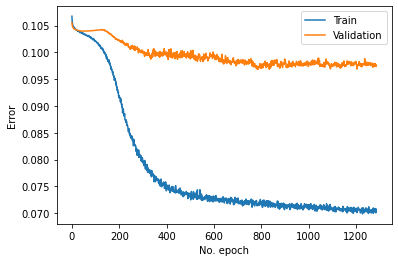

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

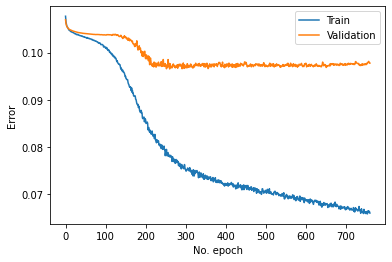

In [ ]:
#Spacey fold-2
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

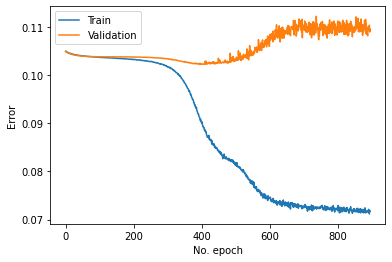

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

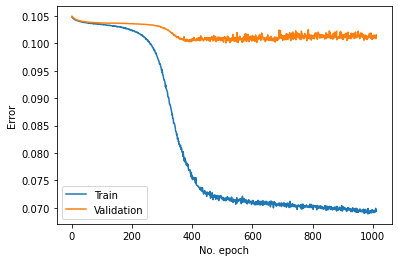

In [ ]:
# Random fold-2
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

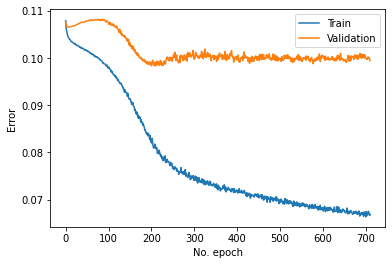

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

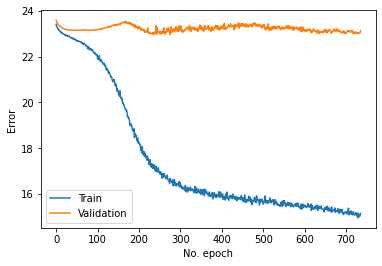

In [ ]:
plt.plot(history.history['mean_absolute_percentage_error'], label='Train')
plt.plot(history.history['val_mean_absolute_percentage_error'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

In [ ]:
model.save_weights('audio_embedding.h5')

In [ ]:
model.save_weights("/content/drive/MyDrive/audio-and-word-embeddings/E3/model_5.h5")

In [ ]:
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 4ms/step - loss: 0.0093 - mean_absolute_error: 0.1122


[0.009296669624745846, 0.11216448247432709]

In [ ]:
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 3ms/step - loss: 1.2906 - mean_absolute_error: 0.9110


[1.2906494140625, 0.9109524488449097]

In [ ]:
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 3ms/step - loss: 1.2765 - mean_absolute_error: 0.9085


[1.276533603668213, 0.9084798097610474]

In [ ]:
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 2ms/step - loss: 1.2765 - mean_absolute_error: 0.9085


[1.276533603668213, 0.9084798097610474]

In [ ]:
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 3ms/step - loss: 1.2868 - mean_absolute_error: 0.9070


[1.2867929935455322, 0.906987726688385]

In [ ]:
# random
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 2ms/step - loss: 1.2409 - mean_absolute_error: 0.8985


[1.2409207820892334, 0.8985073566436768]

In [ ]:
# +3 db
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 3ms/step - loss: 1.2669 - mean_absolute_error: 0.9164


[1.2669308185577393, 0.9164082407951355]

In [ ]:
# +3 db
model.evaluate(x=x_test, y=y_test)

3/3 [==============================] - 0s 3ms/step - loss: 0.1357 - mean_absolute_error: 0.2919


[0.1357341855764389, 0.2918856143951416]

In [ ]:
model.save_weights("/content/drive/MyDrive/audio-and-word-embeddings/E2/model_3.h5")

In [ ]:
model.save("/content/drive/MyDrive/audio-and-word-embeddings/E2/model_3_backup.h5")

In [ ]:
model.save_weights("/content/drive/MyDrive/audio-and-word-embeddings/E2/model_3_backup_weights.h5")

In [ ]:
model.load_weights("/content/drive/MyDrive/audio-and-word-embeddings/E2/model_3.h5")

# Testing

In [ ]:
test_words = ["metallic"]
test_words_vec = vec2(np.array([[s] for s in test_words])).numpy()
p = model.predict(test_words_vec)
# y_test = (y_test - mmin) / (mmax - mmin)
p = p * (mmax - mmin) + mmin

In [ ]:
p

array([[ 0.25198317,  0.31728363,  0.35321951,  0.39033985,  0.35700226,
         0.36942863,  0.41295958,  0.39898539,  0.33982277,  0.15455484,
         0.01975155, -0.03686285, -0.11283827, -0.12049627, -0.21099925,
        -0.21291518, -0.22045732, -0.17478561, -0.11642528, -0.1356082 ,
        -0.0730381 , -0.09327865, -0.06216931, -0.113626  , -0.11594915,
        -0.11071515, -0.07767868, -0.07670951, -0.08573151, -0.15321183,
        -0.18627381, -0.20000625, -0.25737882, -0.22282195, -0.19108486,
        -0.14155269, -0.15687323, -0.19995546, -0.21499968, -0.18873048]])

In [ ]:
p

array([[ 0.25198317,  0.31728363,  0.35321951,  0.39033985,  0.35700226,
         0.36942863,  0.41295958,  0.39898539,  0.33982277,  0.15455484,
         0.01975155, -0.03686285, -0.11283827, -0.12049627, -0.21099925,
        -0.21291518, -0.22045732, -0.17478561, -0.11642528, -0.1356082 ,
        -0.0730381 , -0.09327865, -0.06216931, -0.113626  , -0.11594915,
        -0.11071515, -0.07767868, -0.07670951, -0.08573151, -0.15321183,
        -0.18627381, -0.20000625, -0.25737882, -0.22282195, -0.19108486,
        -0.14155269, -0.15687323, -0.19995546, -0.21499968, -0.18873048]])

In [ ]:
p2.shape

NameError: ignored

In [ ]:
!pip install git+https://github.com/detly/gammatone.git

  Cloning https://github.com/detly/gammatone.git to /tmp/pip-req-build-duvsnf7j
  Running command git clone -q https://github.com/detly/gammatone.git /tmp/pip-req-build-duvsnf7j
     |████████████████████████████████| 154 kB 9.2 MB/s 
  Created wheel for Gammatone: filename=Gammatone-1.0-py3-none-any.whl size=21797 sha256=fd4a78d633dfd39e7631382f18b75d8105f9a1db830bc0f12343a9f5271877c4
  Stored in directory: /tmp/pip-ephem-wheel-cache-igeo5oor/wheels/07/b9/a7/356576d1172ea99bf71c5f5502bb20e951769a34b4e86fe6cc
Successfully built Gammatone


In [ ]:
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP" -O signals.zip && rm -rf /tmp/cookies.txt

--2021-11-15 16:04:02--  https://docs.google.com/uc?export=download&confirm=f1Rz&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP
Resolving docs.google.com (docs.google.com)... 74.125.142.101, 74.125.142.113, 74.125.142.139, ...
Connecting to docs.google.com (docs.google.com)|74.125.142.101|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-0c-1k-docs.googleusercontent.com/docs/securesc/qimeum32tkdcef1qh0q3ne577glu3tbh/7p2opllg2jae8do6uag70ctfcv83vpeh/1636992225000/04739181468756608208/04285095385438852560Z/1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP?e=download [following]
--2021-11-15 16:04:02--  https://doc-0c-1k-docs.googleusercontent.com/docs/securesc/qimeum32tkdcef1qh0q3ne577glu3tbh/7p2opllg2jae8do6uag70ctfcv83vpeh/1636992225000/04739181468756608208/04285095385438852560Z/1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP?e=download
Resolving doc-0c-1k-docs.googleusercontent.com (doc-0c-1k-docs.googleusercontent.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting

In [ ]:
!wget --load-cookies /tmp/cookies.txt "https://docs.google.com/uc?export=download&confirm=$(wget --quiet --save-cookies /tmp/cookies.txt --keep-session-cookies --no-check-certificate 'https://docs.google.com/uc?export=download&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP' -O- | sed -rn 's/.*confirm=([0-9A-Za-z_]+).*/\1\n/p')&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP" -O signals.zip && rm -rf /tmp/cookies.txt
!unzip signals.zip

--2021-11-15 16:04:05--  https://docs.google.com/uc?export=download&confirm=YfQk&id=1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP
Resolving docs.google.com (docs.google.com)... 74.125.142.139, 74.125.142.113, 74.125.142.101, ...
Connecting to docs.google.com (docs.google.com)|74.125.142.139|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://doc-04-ak-docs.googleusercontent.com/docs/securesc/ou5u6ltg5p02e8ponq6kp3uq1tf5m506/idl603ka2v4upnebglujoar4n9jkjh68/1636992225000/04739181468756608208/15164984648692661642Z/1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP?e=download [following]
--2021-11-15 16:04:05--  https://doc-04-ak-docs.googleusercontent.com/docs/securesc/ou5u6ltg5p02e8ponq6kp3uq1tf5m506/idl603ka2v4upnebglujoar4n9jkjh68/1636992225000/04739181468756608208/15164984648692661642Z/1FV5KDNVsBpb1fRp2kmyWxDhL1EfvvqAP?e=download
Resolving doc-04-ak-docs.googleusercontent.com (doc-04-ak-docs.googleusercontent.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting

In [ ]:
from gammatone import filters 
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display

In [ ]:
# Load and listen to original audio sample

x, fs = sf.read('signals/e_gtr_short.wav')
print(f"Loaded {x.shape[0]} samples at fs={fs}")
IPython.display.Audio(x,rate=fs)

Loaded 458317 samples at fs=44100


In [ ]:
# A list of terms taken from the SocialFX Dataset
gain_vector = {}
gain_vector['hot'] = np.flip(np.array([0.797209, -1.287298455, -1.532964082, -1.506539385, -1.396973938, -1.271198913, -1.017866669, -0.528729007, 0.165573584, 0.754400175, 1.073992036, 1.282210725, 1.442060062, 1.568685481, 1.653999697, 1.648503806, 1.53967359, 1.580347112, 1.577686577, 1.205675471, 0.676758791, 0.252821123, 0.075167078, -0.033101099, -0.089115047, -0.1365393, -0.143565939, -0.084299287, -0.051027767, -0.038591153, -0.089749952, -0.192244295, -0.345006204, -0.529255497, -0.724989266, -0.864740603, -0.916542181, -0.839557577, -0.823611993, -0.980958406]))
gain_vector['warm'] = np.flip(np.array([0.806225, 1.970152522, 2.063643883, 2.109621503, 2.019063089, 1.833557153, 1.54050257, 1.253791039, 1.124354285, 0.912120468, 0.479917036, -0.176767683, -0.766548101, -0.982288412, -0.876476603, -0.871483715, -0.986591984, -1.095373269, -1.006018325, -0.665307271, -0.386414479, -0.282319476, -0.236480253, -0.182852135, -0.094328345, 0.115664993, 0.429528178, 0.443207819, 0.225592816, -0.061474359, -0.435409903, -0.866104454, -1.093506922, -1.048872922, -0.838433617, -0.650190554, -0.567333094, -0.666182754, -0.760821358, -0.622340305]))
gain_vector['cold'] = np.flip(np.array([0.56672, -2.034095236, -2.054271815, -2.050160073, -1.971859231, -1.880512554, -1.774836615, -1.588498521, -1.323855231, -0.929419044, -0.477990841, 0.001836709, 0.425480213, 0.710446169, 0.736694949, 0.743315275, 0.699904753, 0.573891718, 0.417793993, 0.336596002, 0.362311733, 0.393507005, 0.31382609, 0.206445573, 0.156956594, 0.131116367, 0.096204939, 0.101053811, 0.198440373, 0.395838345, 0.665566916, 0.984723167, 1.146000944, 0.996436067, 0.733647623, 0.466518535, 0.551724202, 0.883208881, 0.863160135, 0.817721258]))
gain_vector['relaxing'] = np.flip(np.array([0.667283, 2.12661933, 1.972813587, 2.076840264, 2.029614099, 1.828261577, 1.529357681, 1.106721532, 0.574096502, 0.036519114, -0.369146913, -0.763306351, -1.214185152, -1.591751218, -1.730069773, -1.572405592, -1.283399138, -1.112799795, -0.831637822, -0.283981666, 0.018265935, 0.070173219, -0.021844884, -0.107969439, -0.090211942, 0.099998408, 0.417992371, 0.497223147, 0.322845287, 0.05663085, -0.207602229, -0.375132475, -0.362059187, -0.237172682, -0.145072176, -0.271109014, -0.57736182, -0.58486884, -0.355700261, -0.28738431]))
gain_vector['soothing'] = np.flip(np.array([0.668623, -0.342018362, 0.026666401, 0.446729242, 0.870928285, 1.273066751, 1.605112245, 1.788250756, 1.713096735, 1.410331198, 0.944353776, 0.307533749, -0.378830743, -1.014190533, -1.536209856, -1.920257823, -2.106073864, -2.078396015, -1.942651727, -1.623318874, -1.065090653, -0.478780769, 0.026683737, 0.352843499, 0.58902601, 0.684407324, 0.492285815, 0.224337514, 0.199443126, 0.277549186, 0.356415253, 0.388200774, 0.289154264, 0.096006927, 0.001571427, 0.070259291, 0.231924942, 0.189760673, -0.05734363, -0.202312582]))
gain_vector['harsh'] = np.flip(np.array([0.444456, -0.763625387, -1.097657151, -1.109271826, -0.828296799, -0.504376203, -0.175019514, 0.112461643, 0.343172372, 0.48092289, 0.578483124, 0.793573687, 1.1619776, 1.550687911, 1.789115385, 1.813865965, 1.528659423, 1.337018759, 1.303155904, 1.032093521, 0.634841813, 0.406146777, 0.415351652, 0.425582285, 0.305761841, 0.050915992, -0.345361682, -0.840566551, -1.239371225, -1.504682027, -1.659385274, -1.677605366, -1.570754566, -1.349434626, -1.050155243, -0.736486167, -0.341679134, -0.02872275, 0.067719463, 0.195935989]))


In [ ]:
"cold" in train_word_set

False

In [ ]:
# Create filters
# - I have checked the center frequencies and implementation of the filters, and they all match up the same from the paper.
c_freqs = filters.centre_freqs(fs, 40, 20)
fcoefs = filters.make_erb_filters(fs, c_freqs, width=1.0)

In [ ]:
gain_vector['hot'].shape

(40,)

In [ ]:
c_freqs

array([19682.15554706, 17565.97092647, 15674.69916541, 13984.43601948,
       12473.81784111, 11123.75155922,  9917.17335728,  8838.83299953,
        7875.10107956,  7013.7967549 ,  6244.03379044,  5556.08296459,
        4941.2490993 ,  4391.76115962,  3900.67403364,  3461.78075158,
        3069.53403435,  2718.97618016,  2405.67640291,  2125.67483041,
        1875.4324546 ,  1651.78640114,  1451.90995309,  1273.27682334,
        1113.62922426,   970.94933097,   843.43377754,   729.47086383,
         627.62018483,   536.59442499,   455.24308758,   382.53795322,
         317.560084  ,   259.48820883,   207.58834311,   161.20451182,
         119.75045841,    82.702235  ,    49.59158007,    20.        ])

In [ ]:
test_word_set

['agitated',
 'aggravating',
 'congested',
 'cold',
 'metal',
 'tinny',
 'slow',
 'cosy',
 'brave',
 'damp',
 'jagged',
 'distant',
 'fresh',
 'lazy',
 'emotional',
 'anger',
 'whispered',
 'rousing',
 'children',
 'rain',
 'important',
 'fast',
 'music',
 'humble',
 'clarity',
 'cute',
 'bold',
 'splendid',
 'fast-paced',
 'muffled',
 'bag',
 'punchy',
 'spooky',
 'whispering',
 'tiger',
 'hero',
 'wild',
 'fiery',
 'small']

In [ ]:
val_word_set

['graceful',
 'caustic',
 'forgetful',
 'vibrant',
 'creepy',
 'high-pitched',
 'roll',
 'harmonious',
 'ecstasy',
 'cat',
 'meaty',
 'bassy',
 'fuzzy',
 'hot',
 'choppy',
 'rough',
 'fat',
 'prickly',
 'youthful',
 'poor',
 'harsh',
 'muddled',
 'fancy',
 'classy',
 'stormy',
 'disgusting',
 'blaring',
 'moody',
 'airy',
 'sad',
 'icy',
 'honest',
 'loud',
 'relaxed',
 'anticipation',
 'kind',
 'workout',
 'sprightly',
 'fire',
 'booming',
 'discombobulated',
 'mysterious',
 'tight',
 'distracting',
 'grainy',
 'obnoxious',
 'good',
 'hello',
 'grace',
 'sound',
 'hardness',
 'sea',
 'aggressive',
 'scabrous',
 'serious',
 'gentle',
 'gruff',
 'brash',
 'flow',
 'crash',
 'techno',
 'little',
 'high',
 'archaic',
 'game dog',
 'inspirational',
 'drums',
 'tremble',
 'eager',
 'smelly',
 'radical',
 'dry',
 'gradual',
 'full',
 'deafening',
 'darkness',
 'twangy',
 'edge']

In [ ]:
train_word_set

['big',
 'greasy',
 'aidan',
 'charming',
 'upbeat',
 'alluring',
 'sharp',
 'brillante',
 'grating',
 'heat',
 'rich',
 'moan',
 'hard',
 'confident',
 'coarse',
 'sinister',
 'frantic',
 'mournful',
 'frustration',
 'brass',
 'vintage',
 'tranquil',
 'rock',
 'metallic',
 'watery',
 'smooth',
 'sensual',
 'heart-warming',
 'wistful',
 'dull',
 'boxy',
 'pleasurable',
 'food',
 'clear',
 'pop',
 'safe',
 'groovy',
 'drive',
 'roar',
 'powerful',
 'soft',
 'elegant',
 'light',
 'chilly',
 'bear',
 'energized',
 'crunchy',
 'god',
 'steep',
 'foggy',
 'clash',
 'somber',
 'edgy',
 'rhythmic',
 'bouncy',
 'saccharine',
 'rumble',
 'placid',
 'wow',
 'squeaking',
 'favourable',
 'marvellous',
 'exciting',
 'melancholy',
 'guitar',
 'plodding',
 'joy',
 'tender',
 'oxygen',
 'winter',
 'solid',
 'invigorate',
 'boisterous',
 'helpful',
 'nice',
 'noisy',
 'frigid',
 'relaxing',
 'screeching',
 'dramatic',
 'cooing',
 'frosty',
 'surprised',
 'epic',
 'scared',
 'quiet',
 'quick',
 'lindo',

In [ ]:
model.load_weights("/content/spacey-2.h5")

In [ ]:
"harsh" in train_word_set

False

In [ ]:
# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * gain_vector['metal'],axis=1)
IPython.display.Audio(out,rate=fs)

KeyError: ignored

In [ ]:
"hot" in train_word_set

False

In [ ]:
len(val_word_set)

78

In [ ]:
test_words = ["harsh"]
test_words_vec = vec2(np.array([[s] for s in test_words])).numpy()
p = model.predict(test_words_vec)
# y_test = (y_test - mmin) / (mmax - mmin)
p_harsh = p * (mmax - mmin) + mmin

In [ ]:
mmax - mmin

array([8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8.])

In [ ]:
p_harsh

array([[ 0.22757673,  0.16734982,  0.29178286,  0.34401655,  0.28793335,
         0.32909489,  0.32275724,  0.1800561 ,  0.295228  ,  0.25934076,
         0.17672682,  0.02775478,  0.0312109 , -0.04825687, -0.01505971,
         0.00852394, -0.09934974,  0.0079546 ,  0.18866968,  0.07621098,
         0.1860137 ,  0.07186985,  0.1373229 , -0.0296514 ,  0.12340355,
        -0.03520989, -0.01443505, -0.00424647, -0.12974286, -0.16602898,
        -0.24568987, -0.28454304, -0.37195969, -0.38847947, -0.37691474,
        -0.3672595 , -0.38363767, -0.38062048, -0.43752837, -0.28230548]])

In [ ]:
test_words_vec

array([[229]])

In [ ]:
# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * np.flip(p[0, :]),axis=1)
IPython.display.Audio(out,rate=fs)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
p_sharp.shape

(1, 40)

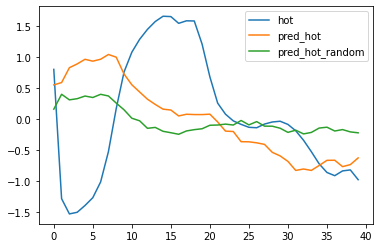

In [ ]:
plt.plot(np.flip(gain_vector['hot']), label="hot")
plt.plot(p_hot[0, :], label="pred_hot")
plt.plot(p_hot_2[0, :], label="pred_hot_random")
plt.legend()

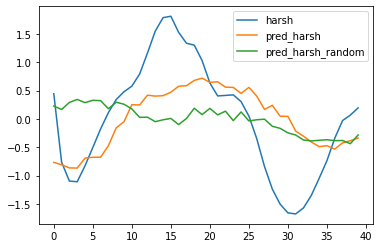

In [ ]:
plt.plot(np.flip(gain_vector['harsh']), label="harsh")
plt.plot(p_harsh[0, :], label="pred_harsh")
plt.plot(p_harsh_2[0, :], label="pred_harsh_random")
plt.legend()

In [ ]:
abs = tf.keras.losses.MeanAbsoluteError(
    reduction="auto", name="mean_absolute_error"
)

In [ ]:
abs(np.flip(gain_vector['harsh']), p_harsh[0, :]).numpy()

0.6505798101425171

In [ ]:
abs(np.flip(gain_vector['harsh']), p_harsh_2[0, :]).numpy()

0.8024032115936279

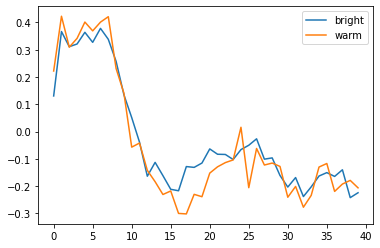

In [ ]:
plt.plot(p_bright[0, :], label="bright")
plt.plot(p_warm[0, :], label="warm")
plt.legend()

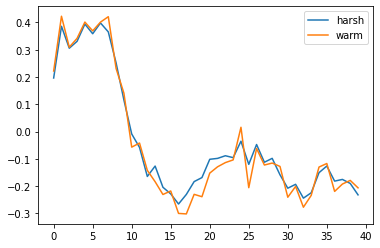

In [ ]:
plt.plot(p_harsh[0, :], label="harsh")
plt.plot(p_warm[0, :], label="warm")
plt.legend()

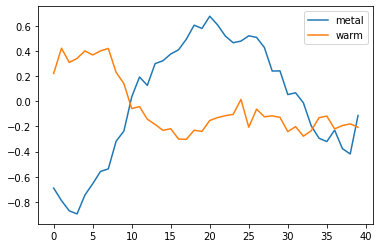

In [ ]:
plt.plot(p_metal[0, :], label="metal")
plt.plot(p_warm[0, :], label="warm")
plt.legend()

In [ ]:
# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * p2[0, :-1],axis=1)
IPython.display.Audio(out,rate=fs)

In [ ]:
"sharp" in train_word_set

True

# Testing with audio files

In [ ]:
# Load and listen to original audio sample

x, fs = sf.read('signals/e_gtr_short.wav')
print(f"Loaded {x.shape[0]} samples at fs={fs}")
IPython.display.Audio(x,rate=fs)

Loaded 458317 samples at fs=44100


In [ ]:
test_words = ["harsh"]
test_words_vec = vec2(np.array([[s] for s in test_words])).numpy()
p = model.predict(test_words_vec)
# y_test = (y_test - mmin) / (mmax - mmin)
p = p * (mmax - mmin) + mmin

# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * np.flip(p[0, :]),axis=1)
IPython.display.Audio(out,rate=fs)

In [ ]:
test_words = ["cold"]
test_words_vec = vec2(np.array([[s] for s in test_words])).numpy()
p2 = model.predict(test_words_vec)
# y_test = (y_test - mmin) / (mmax - mmin)
p2 = p2 * (mmax - mmin) + mmin

# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * np.flip(p2[0, :-1]),axis=1)
IPython.display.Audio(out,rate=fs)

In [ ]:
p == p2

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]])

In [ ]:
"loud" in train_word_set

False